In [2]:
import pandas as pd
import numpy as np
%pip install librosa
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os

Note: you may need to restart the kernel to use updated packages.


In [5]:
dataset_path=r"C:\Users\surya\ML\Speech_Emotion_Recognition"
folders=os.listdir(dataset_path)
print(folders)

['.ipynb_checkpoints', 'Actor_01', 'Actor_02', 'Actor_03', 'Actor_04', 'Actor_05', 'Actor_06', 'Actor_07', 'Actor_08', 'Actor_09', 'Actor_10', 'Actor_11', 'Actor_12', 'Actor_13', 'Actor_14', 'Actor_15', 'Actor_16', 'Actor_17', 'Actor_18', 'Actor_19', 'Actor_20', 'Actor_21', 'Actor_22', 'Actor_23', 'Actor_24', 'audio_speech_actors_01-24', 'Untitled.ipynb']


In [11]:
for folder in os.listdir(dataset_path):
    if folder.startswith("Actor"):
        actor_path=os.path.join(dataset_path,folder)
        print(actor_path)

C:\Users\surya\ML\Speech_Emotion_Recognition\Actor_01
C:\Users\surya\ML\Speech_Emotion_Recognition\Actor_02
C:\Users\surya\ML\Speech_Emotion_Recognition\Actor_03
C:\Users\surya\ML\Speech_Emotion_Recognition\Actor_04
C:\Users\surya\ML\Speech_Emotion_Recognition\Actor_05
C:\Users\surya\ML\Speech_Emotion_Recognition\Actor_06
C:\Users\surya\ML\Speech_Emotion_Recognition\Actor_07
C:\Users\surya\ML\Speech_Emotion_Recognition\Actor_08
C:\Users\surya\ML\Speech_Emotion_Recognition\Actor_09
C:\Users\surya\ML\Speech_Emotion_Recognition\Actor_10
C:\Users\surya\ML\Speech_Emotion_Recognition\Actor_11
C:\Users\surya\ML\Speech_Emotion_Recognition\Actor_12
C:\Users\surya\ML\Speech_Emotion_Recognition\Actor_13
C:\Users\surya\ML\Speech_Emotion_Recognition\Actor_14
C:\Users\surya\ML\Speech_Emotion_Recognition\Actor_15
C:\Users\surya\ML\Speech_Emotion_Recognition\Actor_16
C:\Users\surya\ML\Speech_Emotion_Recognition\Actor_17
C:\Users\surya\ML\Speech_Emotion_Recognition\Actor_18
C:\Users\surya\ML\Speech_Emo

In [20]:
for audio_file in os.listdir(actor_path):
    audio_path=os.path.join(actor_path,audio_file)
    audio,sr=librosa.load(audio_path)
    print(audio_path)
    print("Shape:",audio.shape)
    print("sr",sr)

C:\Users\surya\ML\Speech_Emotion_Recognition\Actor_24\03-01-01-01-01-01-24.wav
Shape: (81667,)
sr 22050
C:\Users\surya\ML\Speech_Emotion_Recognition\Actor_24\03-01-01-01-01-02-24.wav
Shape: (80195,)
sr 22050
C:\Users\surya\ML\Speech_Emotion_Recognition\Actor_24\03-01-01-01-02-01-24.wav
Shape: (80196,)
sr 22050
C:\Users\surya\ML\Speech_Emotion_Recognition\Actor_24\03-01-01-01-02-02-24.wav
Shape: (79460,)
sr 22050
C:\Users\surya\ML\Speech_Emotion_Recognition\Actor_24\03-01-02-01-01-01-24.wav
Shape: (78724,)
sr 22050
C:\Users\surya\ML\Speech_Emotion_Recognition\Actor_24\03-01-02-01-01-02-24.wav
Shape: (77253,)
sr 22050
C:\Users\surya\ML\Speech_Emotion_Recognition\Actor_24\03-01-02-01-02-01-24.wav
Shape: (85346,)
sr 22050
C:\Users\surya\ML\Speech_Emotion_Recognition\Actor_24\03-01-02-01-02-02-24.wav
Shape: (81667,)
sr 22050
C:\Users\surya\ML\Speech_Emotion_Recognition\Actor_24\03-01-02-02-01-01-24.wav
Shape: (90496,)
sr 22050
C:\Users\surya\ML\Speech_Emotion_Recognition\Actor_24\03-01-02-0

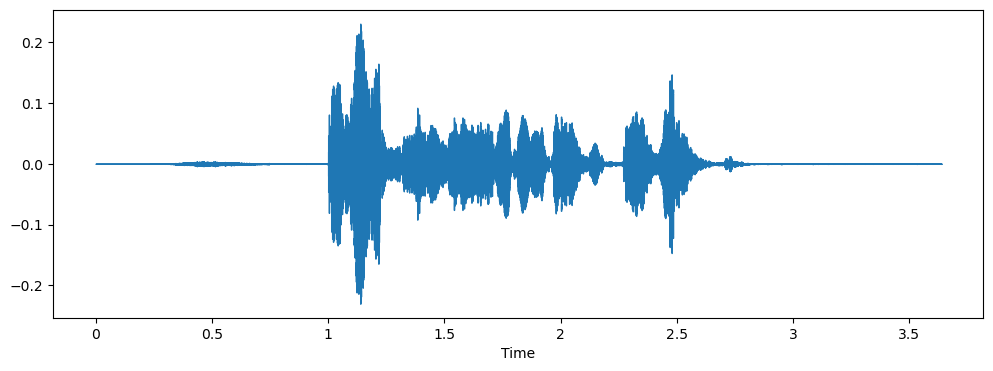

In [18]:
plt.figure(figsize=(12,4))
librosa.display.waveshow(audio,sr=sr)

In [186]:
def extract_features(audio_path):
    audio,sr=librosa.load(audio_path,sr=None)
    audio, _ = librosa.effects.trim(audio)
    audio = librosa.util.normalize(audio)
    
    mfcc=librosa.feature.mfcc(y=audio,sr=sr,n_mfcc=40)
    mfcc_mean=np.mean(mfcc,axis=1)
    mfcc_std = np.std(mfcc,axis=1)

    chroma=librosa.feature.chroma_stft(
         y=audio,
         sr=sr)
    chroma_mean=np.mean(chroma,axis=1)
    chroma_std = np.std(chroma, axis=1)

    rms=librosa.feature.rms(y=audio)
    rms_mean=np.mean(rms,axis=1)
    rms_std = np.std(rms,axis=1)

    zcr=librosa.feature.zero_crossing_rate(audio)
    zcr_mean=np.mean(zcr,axis=1)
    zcr_std = np.std(zcr,axis=1)

    centroid=librosa.feature.spectral_centroid(
         y=audio,
         sr=sr
    )
    centroid_mean=np.mean(centroid,axis=1)
    centroid_std = np.std(centroid,axis=1)

    contrast=librosa.feature.spectral_contrast(
         y=audio,
         sr=sr)
    contrast_mean=np.mean(contrast,axis=1)
    contrast_std = np.std(contrast,axis=1)

    rolloff=librosa.feature.spectral_rolloff(
         y=audio,
         sr=sr
    )
    rolloff_mean=np.mean(rolloff,axis=1)
    rolloff_std=np.std(rolloff,axis=1)

    features=np.hstack((
        mfcc_mean,
        mfcc_std,

        chroma_mean,
        chroma_std,

        rms_mean,
        rms_std,

        zcr_mean,
        zcr_std,

        centroid_mean,
        centroid_std,

        contrast_mean,
        contrast_std,

        rolloff_mean,
        rolloff_std
    ))
    return features

In [187]:
def get_emotion(audio_file):
    parts=audio_file.split('-')
    emotion_code=parts[2]
    emotion_dict = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"}
    return emotion_dict[emotion_code]

In [188]:
def create_dataset(dataset_path):
    dataset=[]
    for actor in os.listdir(dataset_path):
        actor_path=os.path.join(actor)
        if not os.path.isdir(actor_path):
            continue
        for audio_file in os.listdir(actor_path):
            if audio_file.endswith(".wav"):
                audio_path=os.path.join(actor_path,audio_file)
                try:
                    features=extract_features(audio_path)
                    emotion=get_emotion(audio_file)
                    row=list(features)
                    row.append(emotion)
                    dataset.append(row)
                except Exception as e:
                    print("Error Processing file")
                    print (e)
    columns=[]
    for i in range(40):
        columns.append(f"MFCC_Mean_{i+1}")
    for i in range(40):
        columns.append(f"MFCC_STD_{i+1}")
    for i in range(12):
        columns.append(f"Chroma_Mean{i+1}")
    for i in range(12):
        columns.append(f"Chroma_STD_{i+1}")
    
    columns.extend(["RMS_Mean","RMS_STD"])

    columns.extend(["ZCR_Mean","ZCR_STD"])

    columns.extend(["Centroid_Mean","Centroid_STD"])

    for i in range(7):
        columns.append(f"Contrast_Mean{i+1}")
    for i in range(7):
        columns.append(f"Contrast_STD_{i+1}")
    columns.extend(["RollOff_Mean","RollOff_STD"])
    columns.append("Emotion")
    df = pd.DataFrame(dataset, columns=columns)

    return df

In [189]:
features = extract_features(audio_path)

print(len(features))

126


In [190]:
dataset_path = r"C:\Users\surya\ML\Speech_Emotion_Recognition"

df = create_dataset(dataset_path)

In [191]:
df.to_csv("speech_features.csv",index=False)

In [192]:
df

,MFCC_Mean_1,MFCC_Mean_2,MFCC_Mean_3,MFCC_Mean_4,MFCC_Mean_5,MFCC_Mean_6,MFCC_Mean_7,MFCC_Mean_8,MFCC_Mean_9,MFCC_Mean_10,...,Contrast_STD_1,Contrast_STD_2,Contrast_STD_3,Contrast_STD_4,Contrast_STD_5,Contrast_STD_6,Contrast_STD_7,RollOff_Mean,RollOff_STD,Emotion
0,-337.198425,105.834122,4.703499,18.523153,8.154274,20.808151,-4.989314,4.450795,-5.468726,-2.746948,...,8.237610,4.069299,5.343327,4.287011,4.198801,5.156169,4.866263,9534.375000,7370.309353,neutral
1,-365.112823,97.251945,0.847367,17.629940,10.328798,19.593670,-6.221257,5.824074,-5.320165,-5.450251,...,9.067803,4.465693,5.762736,4.517117,4.036969,5.231014,5.068897,10442.557199,7396.500826,neutral
2,-397.269287,88.826836,4.091902,14.538698,7.572285,13.611512,-4.201235,5.421018,-6.086838,-3.690548,...,9.380212,4.029808,5.074805,4.697317,4.218557,5.008004,5.352342,11425.879727,8071.150947,neutral
3,-424.534821,74.249725,5.987121,14.322783,6.465185,13.501793,-2.348783,5.887998,-5.722302,-4.044089,...,9.997869,4.357622,5.330531,4.803650,4.164324,4.565001,5.390544,12561.715846,7630.444618,neutral
4,-380.204559,86.181702,6.601220,16.349792,7.120249,16.466585,-3.636997,5.079800,-6.108876,-0.968453,...,10.051774,4.739274,6.316195,5.337343,5.310067,5.239283,5.485773,11596.810567,7890.101509,calm
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1435,-307.169922,74.691620,-33.609070,5.827080,-18.443110,-6.564035,-23.174395,-7.750366,-25.505241,-13.736091,...,4.926970,6.930320,6.936387,6.502375,5.883951,4.614624,6.532020,8721.394231,4977.077541,surprised
1436,-317.048553,93.531784,-25.040054,4.137374,-23.174587,-7.064046,-28.984379,-8.617523,-16.995031,-14.830855,...,4.983338,6.234339,6.516434,5.669830,4.832859,4.820418,5.592151,7239.034473,4594.493680,surprised
1437,-285.675812,87.277679,-36.286156,8.132503,-20.771439,-4.236350,-33.941833,-10.294116,-17.731674,-14.442936,...,3.971466,6.349741,6.022852,5.278237,5.545083,4.929669,5.698672,8111.646476,4439.315477,surprised
1438,-299.858124,62.639050,-22.390772,17.508253,-17.774605,1.584530,-20.219109,0.472238,-20.740570,-4.194750,...,4.451691,7.692487,5.511122,5.084630,5.006970,3.102874,7.587157,10080.111229,3752.238279,surprised


In [193]:
df.isnull().sum()

MFCC_Mean_1       0
MFCC_Mean_2       0
MFCC_Mean_3       0
MFCC_Mean_4       0
MFCC_Mean_5       0
                 ..
Contrast_STD_6    0
Contrast_STD_7    0
RollOff_Mean      0
RollOff_STD       0
Emotion           0
Length: 127, dtype: int64

<Axes: >

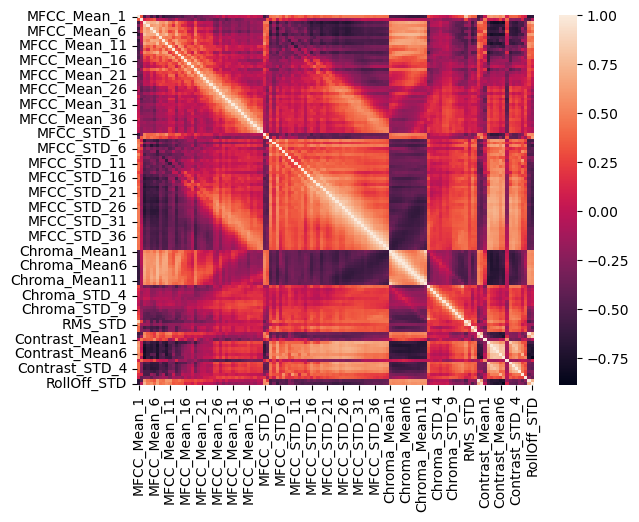

In [194]:
sns.heatmap(df.corr(numeric_only=True))

<Axes: xlabel='Emotion', ylabel='Count'>

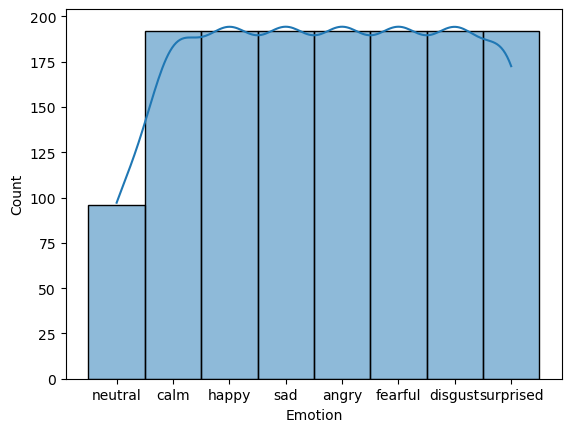

In [195]:
sns.histplot(df['Emotion'], kde=True)

In [196]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Columns: 127 entries, MFCC_Mean_1 to Emotion
dtypes: float64(126), object(1)
memory usage: 1.4+ MB


In [197]:
df.sample(5)

,MFCC_Mean_1,MFCC_Mean_2,MFCC_Mean_3,MFCC_Mean_4,MFCC_Mean_5,MFCC_Mean_6,MFCC_Mean_7,MFCC_Mean_8,MFCC_Mean_9,MFCC_Mean_10,...,Contrast_STD_1,Contrast_STD_2,Contrast_STD_3,Contrast_STD_4,Contrast_STD_5,Contrast_STD_6,Contrast_STD_7,RollOff_Mean,RollOff_STD,Emotion
1360,-380.659241,68.899521,-10.114985,4.383749,1.697882,12.370401,-11.480402,-5.527446,-7.949058,-9.755516,...,9.313171,6.397822,7.037081,5.913208,5.740627,5.633893,7.079159,9857.112233,5985.879013,fearful
971,-406.335510,96.580811,15.095711,27.263136,9.035239,19.812439,6.164378,16.410280,4.601053,-2.992805,...,5.262552,4.724473,4.425905,4.302542,3.801412,4.413738,5.977815,11488.540098,7233.761305,calm
23,-313.329895,119.525391,7.271412,21.665359,12.744190,19.431133,-8.885488,10.965565,-6.721200,-8.814184,...,8.348939,4.399057,5.117181,4.915275,3.791599,5.708067,4.658572,8093.497984,6809.828158,sad
755,-236.538330,64.138000,-46.316257,10.829616,-33.435413,-12.380274,-16.606695,-9.348121,-17.632946,-4.786574,...,6.181168,7.756799,8.951190,7.809069,6.389433,4.754507,6.368203,7410.294524,3138.851545,angry
1366,-415.894592,56.895290,-0.765291,11.621569,-1.776053,12.879088,-4.724576,6.068356,-6.447262,-2.870084,...,9.627189,4.460135,4.468843,4.964659,5.077695,4.261942,7.623682,12843.517946,6950.713080,disgust


In [198]:
df.describe()

,MFCC_Mean_1,MFCC_Mean_2,MFCC_Mean_3,MFCC_Mean_4,MFCC_Mean_5,MFCC_Mean_6,MFCC_Mean_7,MFCC_Mean_8,MFCC_Mean_9,MFCC_Mean_10,...,Contrast_Mean7,Contrast_STD_1,Contrast_STD_2,Contrast_STD_3,Contrast_STD_4,Contrast_STD_5,Contrast_STD_6,Contrast_STD_7,RollOff_Mean,RollOff_STD
count,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,...,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000
mean,-352.606703,81.581083,-8.020652,11.537626,-1.413110,9.124836,-11.678408,0.420195,-9.586197,-7.685172,...,22.242310,6.444202,5.904989,6.146705,5.130405,4.819999,4.621045,6.398697,9611.741899,5889.324523
std,45.435579,17.760375,15.993913,8.893698,8.960617,8.450923,9.074599,6.308189,6.925738,6.339503,...,3.901150,1.415807,1.311911,1.100078,0.914799,0.719855,0.966651,1.208204,1994.833251,1206.691947
min,-461.363129,27.845062,-77.594498,-28.492987,-40.018852,-20.233521,-40.904217,-20.971668,-40.240692,-30.032843,...,14.512490,3.467279,3.054536,3.571688,3.293403,3.185218,2.594161,2.908542,4977.252907,2411.991215
25%,-383.985664,69.720449,-16.776211,6.443197,-7.002291,3.666874,-17.844442,-3.807565,-14.598464,-11.847307,...,19.248451,5.348105,4.822976,5.275221,4.438476,4.281462,3.873984,5.528356,8059.472656,5008.930021
50%,-356.925446,80.458015,-5.445862,12.388685,-0.646267,10.237915,-11.279095,0.719599,-9.751658,-7.102064,...,21.395285,6.158180,5.967216,6.127535,5.015530,4.766355,4.584113,6.339348,9620.626515,5995.651608
75%,-319.524460,92.545288,3.856129,16.952913,5.293587,15.291871,-4.887514,4.728982,-4.033952,-2.738396,...,24.670341,7.428604,6.818332,6.901543,5.669854,5.298730,5.281069,7.174285,11204.415269,6880.128735
max,-215.991257,148.182892,22.603916,36.563427,21.130018,33.188709,10.092592,16.410280,6.087853,7.564384,...,36.326368,11.350590,10.401168,10.422242,9.303144,8.137937,8.926851,10.983801,14598.128981,8380.946464


In [199]:
df['Emotion'].value_counts()

Emotion
calm         192
happy        192
sad          192
angry        192
fearful      192
disgust      192
surprised    192
neutral       96
Name: count, dtype: int64

In [244]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Emotion_encoded']=le.fit_transform(df['Emotion'])
X=df.drop(columns=['Emotion','Emotion_encoded'])
y=df['Emotion_encoded']

In [245]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,
                                              stratify=y)


In [246]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [247]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

In [248]:
lr=LogisticRegression(max_iter=1000)
svm=SVC(kernel='rbf')
rf=RandomForestClassifier(random_state=42,n_estimators=400)
lr.fit(X_train_scaled,y_train)
y_pred_lr=lr.predict(X_test_scaled)
svm.fit(X_train_scaled,y_train)
y_pred_svm=svm.predict(X_test_scaled)
rf.fit(X_train,y_train)
y_pred_rf=rf.predict(X_test)

In [249]:
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report)
print(classification_report(y_test, y_pred_lr))
print("Confusion Matrix LR:\n",confusion_matrix(y_test,y_pred_lr))
print(classification_report(y_test, y_pred_svm))
print("Confusion Matrix SVM:\n",confusion_matrix(y_test,y_pred_svm))
print(classification_report(y_test, y_pred_rf))
print("Confusion Matrix Rf:\n",confusion_matrix(y_test,y_pred_rf))
accu_scores=[]
accu_scores.append(accuracy_score(y_test,y_pred_lr))
accu_scores.append(accuracy_score(y_test,y_pred_svm))
accu_scores.append(accuracy_score(y_test,y_pred_rf))

              precision    recall  f1-score   support

           0       0.64      0.71      0.68        38
           1       0.66      0.82      0.73        38
           2       0.61      0.61      0.61        38
           3       0.60      0.64      0.62        39
           4       0.56      0.49      0.52        39
           5       0.25      0.21      0.23        19
           6       0.48      0.34      0.40        38
           7       0.69      0.74      0.72        39

    accuracy                           0.59       288
   macro avg       0.56      0.57      0.56       288
weighted avg       0.58      0.59      0.58       288

Confusion Matrix LR:
 [[27  1  5  1  3  0  0  1]
 [ 0 31  1  1  0  2  3  0]
 [ 3  1 23  2  2  0  3  4]
 [ 3  2  1 25  5  0  1  2]
 [ 2  0  1  8 19  4  1  4]
 [ 1  4  1  2  2  4  5  0]
 [ 1  8  5  2  3  4 13  2]
 [ 5  0  1  1  0  2  1 29]]
              precision    recall  f1-score   support

           0       0.74      0.66      0.69        38
 

In [250]:
accu_scores

[0.59375, 0.6180555555555556, 0.5902777777777778]

In [251]:
from sklearn.model_selection import GridSearchCV
param_grid={
    'C':[0.1,1,10,100],
    'gamma':[0.001,0.01,0.1,1],
    'kernel':['rbf']
}
grid = GridSearchCV(
    estimator=SVC(class_weight='balanced'),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    verbose=2,
    n_jobs=-1,
)

In [252]:
grid.fit(X_train_scaled, y_train)
print(grid.best_params_)
print(grid.best_score_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
{'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
0.7369508752117448


In [253]:
best_svm=grid.best_estimator_
y_pred_best_svm=best_svm.predict(X_test_scaled)

In [254]:
accuracy_score(y_test,y_pred_best_svm)

0.6944444444444444

In [256]:
import joblib
joblib.dump(grid.best_estimator_,'emotion_model.pkl')
joblib.dump(scaler,'scaler.pkl')
joblib.dump(le,'label_encoder.pkl')

['label_encoder.pkl']

Below code is AI generated

In [212]:
%pip install xgboost

   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   -- ------------------------------------- 3.7/69.5 MB 24.3 MB/s eta 0:00:03
   -- ------------------------------------- 3.7/69.5 MB 24.3 MB/s eta 0:00:03
   -- ------------------------------------- 4.2/69.5 MB 7.8 MB/s eta 0:00:09
   -- ------------------------------------- 4.5/69.5 MB 5.4 MB/s eta 0:00:13
   --- ------------------------------------ 5.8/69.5 MB 5.4 MB/s eta 0:00:12
   --- ------------------------------------ 6.8/69.5 MB 5.4 MB/s eta 0:00:12
   ---- ----------------------------------- 7.9/69.5 MB 5.3 MB/s eta 0:00:12
   ---- ----------------------------------- 8.4/69.5 MB 5.2 MB/s eta 0:00:12
   ----- ---------------------------------- 9.2/69.5 MB 4.9 MB/s eta 0:00:13
   ----- ---------------------------------- 10.0/69.5 MB 4.8 MB/s eta 0:00:13
   ------ --------------------------------- 10.7/69.5 MB 4.7 MB/s eta 0:00:13
   ------ --------------------------------- 12.1/69.5 MB 4.8 MB/s eta 0:00:12
 

In [213]:
from xgboost import XGBClassifier
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.25,        # 25% of 80% = 20%
    random_state=42,
    stratify=y_train_val
)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

X_test_scaled = scaler.transform(X_test)
models = {

    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "SVM":
        SVC(kernel="rbf"),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=300,
            random_state=42
        ),
    "XGBoost":
        XGBClassifier(
            random_state=42,
            eval_metric="mlogloss"
        )}
results = []

for name, model in models.items():

    print("="*60)
    print(name)
    print("="*60)

    # Models that require scaling
    if name in ["Logistic Regression", "SVM"]:

        model.fit(X_train_scaled, y_train)

        train_pred = model.predict(X_train_scaled)
        val_pred = model.predict(X_val_scaled)
        test_pred = model.predict(X_test_scaled)

    # Tree-based models
    else:

        model.fit(X_train, y_train)

        train_pred = model.predict(X_train)
        val_pred = model.predict(X_val)
        test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, train_pred)
    val_acc = accuracy_score(y_val, val_pred)
    test_acc = accuracy_score(y_test, test_pred)

    results.append([
        name,
        train_acc,
        val_acc,
        test_acc
    ])

    print(f"Training Accuracy   : {train_acc:.4f}")
    print(f"Validation Accuracy : {val_acc:.4f}")
    print(f"Testing Accuracy    : {test_acc:.4f}")

    print("\nClassification Report\n")

    print(classification_report(y_test, test_pred))

    print("Confusion Matrix\n")

    print(confusion_matrix(y_test, test_pred))

# ====================================================
# Results Table
# ====================================================

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Train Accuracy",
        "Validation Accuracy",
        "Test Accuracy"
    ]
)
print("\n\n================ FINAL COMPARISON ================\n")

print(results_df.sort_values(
    by="Validation Accuracy",
    ascending=False
))

Logistic Regression
Training Accuracy   : 0.6852
Validation Accuracy : 0.5347
Testing Accuracy    : 0.5000

Classification Report

              precision    recall  f1-score   support

           0       0.64      0.76      0.70        38
           1       0.54      0.55      0.55        38
           2       0.43      0.47      0.45        38
           3       0.48      0.59      0.53        39
           4       0.48      0.33      0.39        39
           5       0.31      0.26      0.29        19
           6       0.39      0.39      0.39        38
           7       0.61      0.51      0.56        39

    accuracy                           0.50       288
   macro avg       0.49      0.49      0.48       288
weighted avg       0.50      0.50      0.49       288

Confusion Matrix

[[29  0  4  1  1  0  3  0]
 [ 1 21  5  3  1  2  5  0]
 [ 5  2 18  4  2  2  4  1]
 [ 4  0  2 23  5  0  0  5]
 [ 1  1  5 11 13  0  4  4]
 [ 0  6  2  0  2  5  4  0]
 [ 2  8  2  2  2  4 15  3]
 [ 3  1  4 